In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout
import shap


In [10]:
# Load CSV
data = pd.read_csv('data/PdM_telemetry.csv')

# Rename columns
data.columns = ['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'model', 'age', 'failure']

# Convert datetime
data['datetime'] = pd.to_datetime(data['datetime'])

# Quick check
data.head()


ValueError: Length mismatch: Expected axis has 6 elements, new values have 9 elements

In [12]:
# Load CSV (headers already exist)
data = pd.read_csv('data/PdM_telemetry.csv')

# Convert datetime column
data['datetime'] = pd.to_datetime(data['datetime'])

# Create a simple failure label for demonstration
# Example: failure if voltage < 140 or vibration > 60
data['failure'] = ((data['volt'] < 140) | (data['vibration'] > 60)).astype(int)

# Quick check
data.head()


,datetime,machineID,volt,rotate,pressure,vibration,failure
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,0


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Features
X = data[['volt', 'rotate', 'pressure', 'vibration']].values

# Target
y = data['failure'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for CNN-LSTM: (samples, timesteps, features)
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Quick check
print(X_train.shape, X_test.shape)


(700880, 1, 4) (175220, 1, 4)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, Flatten

# Build the model
model = Sequential([
    Conv1D(64, kernel_size=1, activation='relu', input_shape=(1, 4)),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # output shape: (batch_size, 1)
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)


Epoch 1/5
17522/17522 ━━━━━━━━━━━━━━━━━━━━ 67s 4ms/step - accuracy: 0.9928 - loss: 0.0271 - val_accuracy: 0.9983 - val_loss: 0.0042
Epoch 2/5
17522/17522 ━━━━━━━━━━━━━━━━━━━━ 91s 4ms/step - accuracy: 0.9975 - loss: 0.0058 - val_accuracy: 0.9985 - val_loss: 0.0034
Epoch 3/5
17522/17522 ━━━━━━━━━━━━━━━━━━━━ 78s 4ms/step - accuracy: 0.9978 - loss: 0.0051 - val_accuracy: 0.9984 - val_loss: 0.0037
Epoch 4/5
17522/17522 ━━━━━━━━━━━━━━━━━━━━ 73s 4ms/step - accuracy: 0.9982 - loss: 0.0044 - val_accuracy: 0.9987 - val_loss: 0.0032
Epoch 5/5
17522/17522 ━━━━━━━━━━━━━━━━━━━━ 62s 4ms/step - accuracy: 0.9983 - loss: 0.0039 - val_accuracy: 0.9992 - val_loss: 0.0025


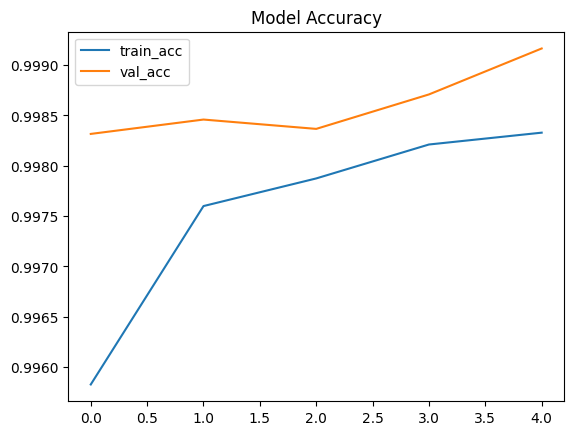

5476/5476 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9994 - loss: 0.0023
Test Accuracy: 0.9993


In [17]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Evaluate on test data
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step 


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
88/88 ━━━━━━━━━━━━━━━━━━━

C:\Users\Sourodip\AppData\Local\Temp\ipykernel_25776\1897666791.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\Sourodip\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


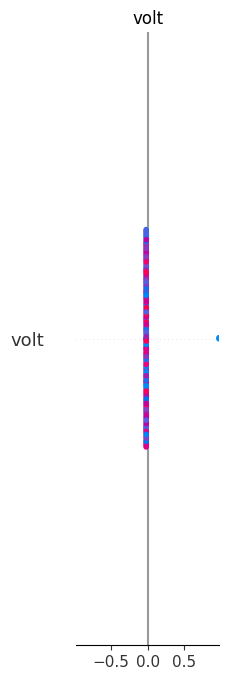

In [21]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Define a wrapper function to reshape input for your model
def model_predict_wrapper(X):
    # X comes in shape (samples, features), reshape to (samples, 1, features)
    X_reshaped = X.reshape((X.shape[0], 1, X.shape[1]))
    return model.predict(X_reshaped)

# Use small subset to save memory
X_train_subset = X_train.reshape((X_train.shape[0], X_train.shape[2]))[:200]
X_test_subset  = X_test.reshape((X_test.shape[0], X_test.shape[2]))[:200]

# Create KernelExplainer
explainer = shap.KernelExplainer(model_predict_wrapper, X_train_subset)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_subset)

# Plot summary
shap.summary_plot(
    shap_values, 
    X_test_subset, 
    feature_names=['volt', 'rotate', 'pressure', 'vibration']
)
